# Cognitive Load Detection with AI

This notebook explores how machine learning can classify cognitive load levels using simulated EEG-like brain signal data.

The goal of this experiment is to explore the intersection of artificial intelligence, neuroscience, and human cognition.

We simulate neural signal features, visualize signal patterns, and train a machine learning model to detect cognitive load levels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
np.random.seed(42)

samples_per_class = 100
features = 10

low_load = np.random.normal(loc=0.2, scale=0.1, size=(samples_per_class, features))
medium_load = np.random.normal(loc=0.5, scale=0.1, size=(samples_per_class, features))
high_load = np.random.normal(loc=0.8, scale=0.1, size=(samples_per_class, features))

X = np.vstack([low_load, medium_load, high_load])

y = np.array([0]*samples_per_class + [1]*samples_per_class + [2]*samples_per_class)

In [3]:
feature_names = [f"signal_{i+1}" for i in range(features)]

df = pd.DataFrame(X, columns=feature_names)

df["cognitive_load"] = y

df.head()

,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9,signal_10,cognitive_load
0,0.249671,0.186174,0.264769,0.352303,0.176585,0.176586,0.357921,0.276743,0.153053,0.254256,0
1,0.153658,0.153427,0.224196,0.008672,0.027508,0.143771,0.098717,0.231425,0.109198,0.058770,0
2,0.346565,0.177422,0.206753,0.057525,0.145562,0.211092,0.084901,0.237570,0.139936,0.170831,0
3,0.139829,0.385228,0.198650,0.094229,0.282254,0.077916,0.220886,0.004033,0.067181,0.219686,0
4,0.273847,0.217137,0.188435,0.169890,0.052148,0.128016,0.153936,0.305712,0.234362,0.023696,0


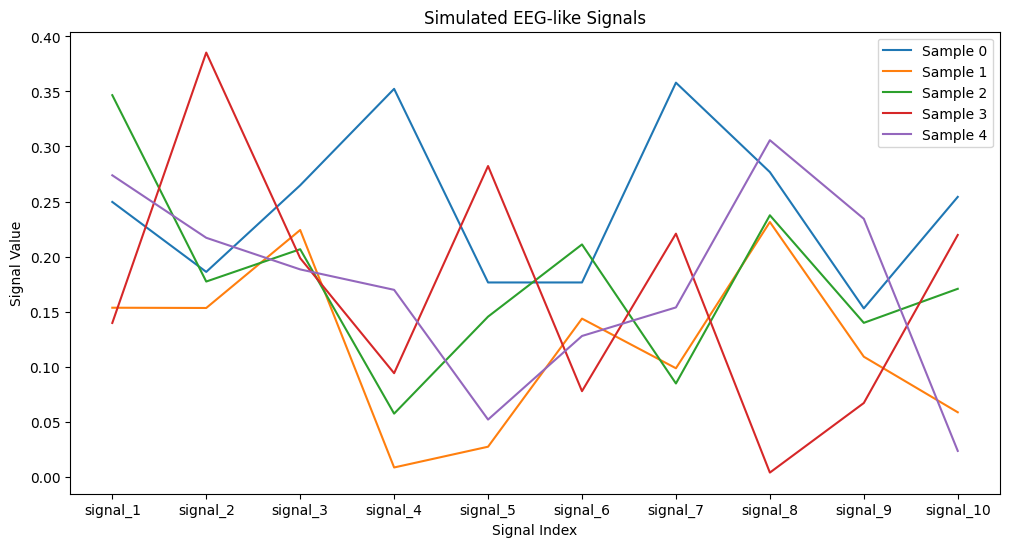

In [4]:
plt.figure(figsize=(12,6))

for i in range(5):
    plt.plot(df.loc[i, feature_names], label=f"Sample {i}")

plt.title("Simulated EEG-like Signals")
plt.xlabel("Signal Index")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

In [5]:
X = df[feature_names]
y = df["cognitive_load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

